In [1]:
from dotenv import load_dotenv
import os
import torch
from torch.distributed.tensor.parallel import loss_parallel
from torch.nn import functional as F
import torch.nn as nn
from tqdm import trange

#from prepare_data import PreparedDataset
from prepare_data import ds_train, ds_test, Tkn, dl_train, dl_test

from torch.optim.lr_scheduler import OneCycleLR

load_dotenv()

# MODEL WEIGHTS
DIM_IMAGE_EMBEDDING = 512
DIM_ATTENTION = 128
D_PIC = 400
N_HEAD_ATTENTION = 32

# PICTURE
N_CONTEXT = 768  # num of patched in picture
W = int(os.getenv("W"))
H = int(os.getenv("H"))
KERNEL = 20

# TEXT PARAMETERS
MAX_LEN_OF_TEXT_CONTEXT = 188 + 1  # 187 - max len of tokens sequence (mean text in utf-8). 1 - special token for start of sequence
DIM_TEXT_EMBEDDING = 128
DIM_TEXT_ATTENTION = 64
N_HEAD_LATEX_ATTENTION = 32
VOCAB_SIZE = 303

# CROSS-MECHANISM PARAMETERS
DIM_CROSS_EMBEDDING = 512
N_HEAD_CROSS_ATTENTION = 32
DIM_CROSS_ATTENTION = 128

device = "cuda" if torch.cuda.is_available() else "cpu"


@torch.no_grad()
def precompute_theta_2D_per_frequencies(head_size: int, theta=10000.0):
    m_x = torch.arange(0, W // KERNEL).repeat(H // KERNEL).to(device)
    m_y = torch.arange(0, H // KERNEL).repeat_interleave(W // KERNEL).to(device)
    theta_pairs_numerator = torch.arange(0, head_size // 2, 2).float()
    theta = 1.0 / (theta ** (2 * theta_pairs_numerator / head_size)).to(device)
    freqs_x = torch.outer(m_x, theta).float()
    freqs_y = torch.outer(m_y, theta).float()
    freqs_complex_x = torch.polar(torch.ones_like(freqs_x), freqs_x)
    freqs_complex_y = torch.polar(torch.ones_like(freqs_y), freqs_y)
    return freqs_complex_x, freqs_complex_y  # (T, head_size // 2)

    # theta_pairs_numerator = torch.arange(0, head_size, 2).float() # i of each pair in emb
    # theta = 1.0 / (theta ** (2 * theta_pairs_numerator / head_size)).to(device)
    # m = torch.arange(m, device=device)
    # freqs = torch.outer(m, theta).float()
    # freqs_complex = torch.polar(torch.ones_like(freqs), freqs) # convert to complex space based on Euler's formula e ^ (it)
    # return freqs_complex #(T, head_size // 2)


def apply_rotary_2D_embeddings(x: torch.Tensor, freqs_complex_x: torch.Tensor, freqs_complex_y: torch.Tensor):
    v_x, v_y = torch.chunk(x, 2, dim=-1)  # each: (B, T, head_size // 2)
    v_x_complex = torch.view_as_complex(v_x.float().reshape(*v_x.shape[:-1], -1, 2))  # (B, T, head_size // 4)
    v_y_complex = torch.view_as_complex(v_y.float().reshape(*v_y.shape[:-1], -1, 2))  # (B, T, head_size // 4)
    freqs_complex_x = freqs_complex_x.unsqueeze(0)
    freqs_complex_y = freqs_complex_y.unsqueeze(0)
    v_x_rotated = v_x_complex * freqs_complex_x
    v_y_rotated = v_y_complex * freqs_complex_y
    v_x_out = torch.view_as_real(v_x_rotated)  # (B, T, head_size // 4, 2)
    v_y_out = torch.view_as_real(v_y_rotated)  # (B, T, head_size // 4, 2)
    v_x_out = v_x_out.reshape(*v_x.shape)
    v_y_out = v_y_out.reshape(*v_y.shape)
    x_out = torch.cat([v_x_out, v_y_out], dim=-1)
    return x_out.type_as(x).to(device)

    # x_complex = torch.view_as_complex(x.float().reshape(*x.shape[:-1], -1, 2)) # (B, T, head_size // 2)
    # freqs_complex = freqs_complex.unsqueeze(0) # (1, T, head_size // 2)
    # x_rotated = x_complex * freqs_complex
    # x_out = torch.view_as_real(x_rotated) #(B, T, head_size // 2, 2)
    # x_out = x_out.reshape(*x.shape)
    # return x_out.type_as(x).to(device)


@torch.no_grad()
def precompute_theta_1D_per_frequencies(head_size: int, theta=10000.0, m=MAX_LEN_OF_TEXT_CONTEXT):
    theta_pairs_numerator = torch.arange(0, head_size, 2).float()  # i of each pair in emb
    theta = 1.0 / (theta ** (2 * theta_pairs_numerator / head_size)).to(device)
    m = torch.arange(m, device=device)
    freqs = torch.outer(m, theta).float()
    freqs_complex = torch.polar(torch.ones_like(freqs),
                                freqs)  # convert to complex space based on Euler's formula e ^ (it)
    return freqs_complex  # (T, head_size // 2)


def apply_rotary_1D_embeddings(x: torch.Tensor, freqs_complex):
    B, N_heads, T, C = x.size()
    x_complex = torch.view_as_complex(x.float().reshape(*x.shape[:-1], -1, 2))  # (B, T, head_size // 2)
    freqs_complex = freqs_complex[:T, :].unsqueeze(0)  # (1, T, head_size // 2) T = T_latex
    x_rotated = x_complex * freqs_complex
    x_out = torch.view_as_real(x_rotated)  # (B, T, head_size // 2, 2)
    x_out = x_out.reshape(*x.shape)
    return x_out.type_as(x).to(device)



class AttentionHead(nn.Module):
    def __init__(self, head_size, freqs_complex_x: torch.Tensor,
                 freqs_complex_y: torch.Tensor):  # patch dim - dim of embedding space, head_size - dim of head space
        super().__init__()
        self.freqs_complex_x, self.freqs_complex_y = freqs_complex_x, freqs_complex_y
        self.key = nn.Linear(DIM_IMAGE_EMBEDDING, N_HEAD_ATTENTION * head_size, bias=False)
        self.query = nn.Linear(DIM_IMAGE_EMBEDDING, N_HEAD_ATTENTION * head_size, bias=False)
        self.value = nn.Linear(DIM_IMAGE_EMBEDDING, N_HEAD_ATTENTION * head_size, bias=False)
        self.head_size = head_size

    def forward(self, x):
        B, T, C = x.shape # (batch, count of elements, count of features)
        k = self.key(x) # (B, T, N_head * head_size)
        k = torch.reshape(k, (B, T, N_HEAD_ATTENTION, self.head_size))
        k = k.permute(0, 2, 1, 3) # (B, N_head, T, head_size)
        k = apply_rotary_2D_embeddings(k, self.freqs_complex_x, self.freqs_complex_y)

        q = self.query(x) # (B, T, N_head * head_size)
        q = torch.reshape(q, (B, T, N_HEAD_ATTENTION, self.head_size))
        q = q.permute(0, 2, 1, 3) # (B, N_head, T, head_size)
        q = apply_rotary_2D_embeddings(q, self.freqs_complex_x, self.freqs_complex_y)

        v = self.value(x) # (B, N_head, T, head_size)
        v = torch.reshape(v, (B, T, N_HEAD_ATTENTION, self.head_size))
        v = v.permute(0, 2, 1, 3) # (B, N_head, T, head_size)
        wei = (q @ k.transpose(-2, -1) / (self.head_size ** 0.5))  # (B, N_heads, T, T)
        softwei = F.softmax(wei, dim=-1)
        out = softwei @ v
        return out  # (B, N_heads, T, head_size)


class MultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.freqs_complex_x, self.freqs_complex_y = precompute_theta_2D_per_frequencies(DIM_ATTENTION)
        # self.heads = nn.ModuleList(
        #     [AttentionHead(DIM_ATTENTION, self.freqs_complex_x, self.freqs_complex_y) for i in range(N_HEAD_ATTENTION)])
        self.attention_heads = AttentionHead(DIM_ATTENTION, self.freqs_complex_x, self.freqs_complex_y)
        self.proj = nn.Linear(N_HEAD_ATTENTION * DIM_ATTENTION, DIM_IMAGE_EMBEDDING)

    def forward(self, x):
        # out = torch.cat([h(x) for h in self.heads], dim=-1)
        B, T, C = x.size()
        out = self.attention_heads(x) # (B, N_head, T, head_size)
        out = out.transpose(1, 2) # (B, T, N_head, head_size)
        out = out.reshape(B, T, -1) # (B, T, N_head * head_size)
        out = self.proj(out)
        return out  # (B, T, DIM_IMAGE_EMBEDDING)


class FeedForward(nn.Module):
    def __init__(self, embedding_in, embedding_out=None):
        if embedding_out == None:
            embedding_out = embedding_in
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_in, embedding_in * 4),
            nn.ReLU(),
            nn.Linear(embedding_in * 4, embedding_out)
        )

    def forward(self, x):
        return self.net(x)


class ResViTBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.att = MultiHeadAttention()
        self.mlp = FeedForward(DIM_IMAGE_EMBEDDING)
        self.ln1 = nn.LayerNorm(DIM_IMAGE_EMBEDDING)
        self.ln2 = nn.LayerNorm(DIM_IMAGE_EMBEDDING)

    def forward(self, x):
        x = x + self.att(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x  # (B, T, DIM_IMAGE_EMBEDDING)


class AttentionHead_Latex_withMask(nn.Module):
    def __init__(self, head_size,
                 freqs_complex: torch.Tensor):  # patch dim - dim of embedding space, head_size - dim of head space
        super().__init__()
        self.freqs_complex = freqs_complex
        self.key = nn.Linear(DIM_TEXT_EMBEDDING, N_HEAD_LATEX_ATTENTION * head_size, bias=False)
        self.query = nn.Linear(DIM_TEXT_EMBEDDING, N_HEAD_LATEX_ATTENTION * head_size, bias=False)
        self.value = nn.Linear(DIM_TEXT_EMBEDDING, N_HEAD_LATEX_ATTENTION * head_size, bias=False)
        self.head_size = head_size

    def forward(self, x_text_emb, x_latex_mask):
        B, T, C = x_text_emb.shape  # (batch, count of elements, count of features)
        k = self.key(x_text_emb)  # (B, T, N_heads_latex * head_size)
        k = torch.reshape(k, (B, T, N_HEAD_LATEX_ATTENTION, self.head_size))
        k = k.permute(0, 2, 1, 3) # (B, N_heads_latex, T, head_size)
        k = apply_rotary_1D_embeddings(k, self.freqs_complex)

        q = self.query(x_text_emb)  # (B, T, N_heads_latex * head_size)
        q = torch.reshape(q, (B, T, N_HEAD_LATEX_ATTENTION, self.head_size))
        q = q.permute(0, 2, 1, 3) # (B, N_heads_latex, T, head_size)
        q = apply_rotary_1D_embeddings(q, self.freqs_complex)

        v = self.value(x_text_emb)  # (B, T, N_heads_latex * head_size)
        v = torch.reshape(v, (B, T, N_HEAD_LATEX_ATTENTION, self.head_size))
        v = v.permute(0, 2, 1, 3) # (B, N_heads_latex, T, head_size)

        wei = (q @ k.transpose(-2, -1) / (self.head_size ** 0.5))  # (B, N_heads_latex, T, T)
        trill = torch.tril(torch.ones((T, T))).to(device)
        wei = wei.masked_fill(trill == 0, float("-inf"))  # trial mask
        # print(x_latex_mask.unsqueeze(1).unsqueeze(1).size())
        # print(wei.size())
        x_latex_mask = x_latex_mask.unsqueeze(1).unsqueeze(2).expand(B, N_HEAD_LATEX_ATTENTION, T, T)
        wei = wei.masked_fill(x_latex_mask == 0, float("-inf"))  # padding mask (by rows)
        softwei = F.softmax(wei, dim=-1)
        out = softwei @ v
        return out  # (B, N_heads_latex, T, head_size)


class MultiHeadAttention_LaTeX(nn.Module):
    def __init__(self):
        super().__init__()
        self.freqs_complex = precompute_theta_1D_per_frequencies(DIM_TEXT_ATTENTION)
        # self.heads = nn.ModuleList([AttentionHead_Latex_withMask(DIM_TEXT_ATTENTION, self.freqs_complex) for i in
        #                             range(N_HEAD_LATEX_ATTENTION)])
        self.lat_attention_heads = AttentionHead_Latex_withMask(DIM_TEXT_ATTENTION, self.freqs_complex)
        self.proj = nn.Linear(N_HEAD_LATEX_ATTENTION * DIM_TEXT_ATTENTION, DIM_TEXT_EMBEDDING)

    def forward(self, x_text_emb, x_latex_mask):
        B, T, C = x_text_emb.size()
        # out = torch.cat([h(x_text_emb, x_latex_mask) for h in self.heads], dim=-1)
        out = self.lat_attention_heads(x_text_emb, x_latex_mask) # (B, N_heads_latex, T, head_size)
        out = out.transpose(1, 2) # (B, T, N_heads_latex, head_size)
        out = out.reshape(B, T, -1) # (B, T, N_heads_latex * head_size)
        out = self.proj(out)
        return out  # (B, T, DIM_TEXT_EMBEDDING)


class ResLaTeXBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.att = MultiHeadAttention_LaTeX()
        self.mlp = FeedForward(DIM_TEXT_EMBEDDING)
        self.ln1 = nn.LayerNorm(DIM_TEXT_EMBEDDING)
        self.ln2 = nn.LayerNorm(DIM_TEXT_EMBEDDING)

    def forward(self, X):  # x_text_emb, x_latex_mask
        x_text_emb, x_latex_mask = X
        x = x_text_emb + self.att(self.ln1(x_text_emb), x_latex_mask)
        x = x_text_emb + self.mlp(self.ln2(x))
        return x  # (B, T, DIM_TEXT_EMBEDDING)


class Cross_AttentionHead_withMask(nn.Module):
    def __init__(self, head_size, freqs_complex_latex, freqs_complex_image_x,
                 freqs_complex_image_y):  # patch dim - dim of embedding space, head_size - dim of head space
        super().__init__()
        self.freqs_complex = freqs_complex_latex
        self.freqs_complex_image_x = freqs_complex_image_x
        self.freqs_complex_image_y = freqs_complex_image_y

        self.key = nn.Linear(DIM_IMAGE_EMBEDDING, N_HEAD_CROSS_ATTENTION * head_size, bias=False) # (B, T_k, N_heads_cross * head_size)
        self.query = nn.Linear(DIM_TEXT_EMBEDDING, N_HEAD_CROSS_ATTENTION * head_size, bias=False) # (B, T_k, N_heads_cross * head_size)
        self.value = nn.Linear(DIM_IMAGE_EMBEDDING, N_HEAD_CROSS_ATTENTION * head_size, bias=False) # (B, T_k, N_heads_cross * head_size)
        self.head_size = head_size

    def forward(self, x_image, x_text_emb, x_latex_mask):
        B_k, T_k, C_k = x_image.shape  # (batch, count of elements, count of features)
        B_q, T_q, C_q = x_text_emb.shape  # (batch, count of elements, count of features)

        k = self.key(x_image)  # (B, T_k, N_heads_cross * head_size)
        k = torch.reshape(k, (B_k, T_k, N_HEAD_CROSS_ATTENTION, self.head_size))
        k = k.permute(0, 2, 1, 3) # (B, N_heads_cross, T_k, head_size)
        k = apply_rotary_2D_embeddings(k, self.freqs_complex_image_x, self.freqs_complex_image_y)

        q = self.query(x_text_emb)  # (B, T_q, N_heads_cross * head_size)
        q = torch.reshape(q, (B_q, T_q, N_HEAD_CROSS_ATTENTION, self.head_size)) # (B, T_q, N_heads_cross, head_size)
        q = q.permute(0, 2, 1, 3) # (B, N_heads_cross, T_q, head_size)
        q = apply_rotary_1D_embeddings(q, self.freqs_complex)

        v = self.value(x_image)  # (B, T_k, N_heads_cross * head_size)
        v = torch.reshape(v, (B_k, T_k, N_HEAD_CROSS_ATTENTION, self.head_size))
        v = v.permute(0, 2, 1, 3) # (B, N_heads_cross, T_k, head_size)
        wei = (q @ k.transpose(-2, -1) / (self.head_size ** 0.5))  # (B, N_heads_cross, T_k, T_k)


        softwei = F.softmax(wei, dim=-1)
        out = softwei @ v
        # x_latex_mask = x_latex_mask.unsqueeze(-1).unsqueeze(-1).expand(B_q, N_HEAD_CROSS_ATTENTION, T_q, T_k)
        x_latex_mask = x_latex_mask.unsqueeze(1).unsqueeze(-1).expand(B_q, N_HEAD_CROSS_ATTENTION, T_q, self.head_size)
        out = out * x_latex_mask
        return out  # (B, N_heads_cross, T_q, head_size)


class Cross_MultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.freqs_complex_latex = precompute_theta_1D_per_frequencies(DIM_CROSS_ATTENTION)
        self.freqs_complex_image_x, self.freqs_complex_image_y = precompute_theta_2D_per_frequencies(
            DIM_CROSS_ATTENTION)

        # self.heads = nn.ModuleList([Cross_AttentionHead_withMask(DIM_CROSS_ATTENTION, self.freqs_complex_latex,
        #                                                          self.freqs_complex_image_x, self.freqs_complex_image_y)
        #                             for i in range(N_HEAD_CROSS_ATTENTION)])
        self.cross_attention_heads = Cross_AttentionHead_withMask(DIM_CROSS_ATTENTION, self.freqs_complex_latex, self.freqs_complex_image_x, self.freqs_complex_image_y)
        self.proj = nn.Linear(N_HEAD_CROSS_ATTENTION * DIM_CROSS_ATTENTION, DIM_CROSS_EMBEDDING)

    def forward(self, x_image, x_latex, x_latex_mask):
        B_q, T_q, C_q = x_latex.size()

        # out = torch.cat([h(x_image, x_latex, x_latex_mask) for h in self.heads], dim=-1)
        out = self.cross_attention_heads(x_image, x_latex, x_latex_mask) # (B, N_heads_cross, T_q, head_size)
        out = out.transpose(1, 2) # (B, T_q, N_heads_cross, head_size)
        out = out.reshape(B_q, T_q, -1) # (B, T, N_heads_latex * head_size)
        out = self.proj(out)
        return out  # (B, T_latex, DIM_CROSS_EMBEDDING)


class CrossAttentionBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.att = Cross_MultiHeadAttention()
        self.mlp = FeedForward(DIM_CROSS_EMBEDDING)
        self.ln1 = nn.LayerNorm(DIM_IMAGE_EMBEDDING)
        self.ln2 = nn.LayerNorm(DIM_TEXT_EMBEDDING)
        self.proj_latex = FeedForward(DIM_TEXT_EMBEDDING, embedding_out=DIM_CROSS_EMBEDDING)
        self.gate = nn.Linear(DIM_CROSS_EMBEDDING, DIM_CROSS_EMBEDDING)

    def forward(self, X):
        x_latex, x_image, x_latex_mask = X
        # x_latex (B, T_latex, DIM_TEXT_EMBEDDING)
        # x_image (B, T=768, DIM_IMAGE, DIM_IMAGE_EMBEDDING)
        x_latex = self.ln2(x_latex)
        x_latex_projected = self.proj_latex(x_latex)
        #x = x_latex_projected + self.att(self.ln1(x_image), x_latex, x_latex_mask)  # (B, T_latex=190, DIM_CROSS_EMBEDDING)
        k = 0.05 + F.sigmoid(self.gate(x_latex_projected)) * 0.5 # 0.1 -> 0.55
        x = x_latex_projected * k + (1 - k) * self.att(self.ln1(x_image), x_latex, x_latex_mask)# (B, T_latex=190,DIM_CROSS_EMBEDDING)

        x = x + self.mlp(x)
        return x  # (B, T_latex, DIM_CROSS_EMBEDDING)


class FormulaAI(nn.Module):
    def __init__(self):
        super().__init__()
        self.image_to_emb = nn.Linear(D_PIC, DIM_IMAGE_EMBEDDING)
        self.VIT_transformers = nn.Sequential(
            ResViTBlock(),
            ResViTBlock(),
        )
        self.latex_transformers = nn.Sequential(
            ResLaTeXBlock()
        )
        self.token_embedding_table = nn.Embedding(VOCAB_SIZE + 1, DIM_TEXT_EMBEDDING)
        self.cross_attention = nn.Sequential(
            CrossAttentionBlock()
        )
        self.final_mlp = FeedForward(DIM_CROSS_EMBEDDING, VOCAB_SIZE + 1)

    def forward(self, X, mode="train"):
        model.train()
        if mode == "train":
            x_image, x_latex, y = X
            y = y.to(device)
        else:
            x_image, x_latex = X
        x_image = x_image.to(device)
        x_latex = x_latex.to(device)


        x_image_emb = self.image_to_emb(x_image)
        x_image_VIT = self.VIT_transformers(x_image_emb)  # (B, T_image, DIM_IMAGE_EMBEDDING)

        # x_latex:
        # [[301, 178, 204, 303, 303, .., 303]]     [302] - not here, because it's x_latex, not target

        x_latex_mask = Tkn.mask_padding(x_latex).to(device)
        # print("маска", x_latex_mask.size())
        x_text_emb = self.token_embedding_table(x_latex)  # (B, T, DIM_TEXT_EMBEDDING)
        x_processed_latex = self.latex_transformers((x_text_emb, x_latex_mask))  # (B, T_latex, DIM_TEXT_EMBEDDING)
        logits = self.cross_attention(
            (x_processed_latex, x_image_VIT, x_latex_mask))  # (B, T_latex, DIM_CROSS_EMBEDDING)
        logits = self.final_mlp(logits)  # (B, T_latex, vocab_size)

        B, T_latex, voc = logits.shape

        if mode == "train":
            logits = logits.view(B * T_latex, voc)
            targets = y.view(B * T_latex)
            loss = F.cross_entropy(logits, targets, ignore_index=Tkn.padding)
        else:
            loss = None

        return logits, loss

    def generate(self, x, MAX_NUM_TOKENS):
        model.eval()
        with torch.no_grad():
            x_image, idx = x
            idx = idx.to(device)
            x_image = x_image.to(device)
            # print(x_image.size())
            # print(idx.size())
            # (B, T) array of indices
            for _ in range(MAX_NUM_TOKENS):
                # get the predictions
                logits, loss = self((x_image, idx), mode="test") # (B, T, voc)
                logits = logits[:, -1, :] # (B, voc)
                probs = F.softmax(logits, dim=-1) # get probabilities 1: [0,5; 0,02 .. ] -> 1
                idx_next = torch.argmax(probs, dim=-1) # predict next token (B)
                idx = torch.cat((idx, idx_next.unsqueeze(0)), dim=1)
        return idx



# ---- TRAIN ----
model = FormulaAI().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, betas=(0.95, 0.999))
scheduler = OneCycleLR(
    optimizer,
    max_lr=4e-3, # Пиковое значение LR
    steps_per_epoch=len(dl_train), # Количество батчей в одной эпохе
    epochs=1, # Сколько всего эпох
    pct_start=0.3,   # 30% времени идем вверх, 70% — вниз
    anneal_strategy='cos'
)

EPOCHS = 1
losses = []

загрузка датасета MathWriting-human...
датасет MathWriting-human загружен успешно


In [2]:
checkpoint = torch.load("checkpoints_28.03.26/checkpoint_Last.pt")
model.load_state_dict(checkpoint["model"])

<All keys matched successfully>

In [6]:
losses

[5.745639801025391,
 5.582788944244385,
 5.380870342254639,
 5.208767890930176,
 4.976306915283203,
 4.7427191734313965,
 4.700534343719482,
 4.575854301452637,
 4.488369941711426,
 4.480634689331055,
 4.395826816558838,
 4.475839614868164,
 4.425195693969727,
 4.355846405029297,
 4.365588188171387,
 4.324338436126709,
 4.415419101715088,
 4.334280967712402,
 4.272014617919922,
 4.231822967529297,
 4.300865650177002,
 4.316314697265625,
 4.247799873352051,
 4.256890773773193,
 4.273338317871094,
 4.267265319824219,
 4.237080097198486,
 4.204861164093018,
 4.160055637359619,
 4.1676154136657715,
 4.263214111328125,
 4.206501483917236,
 4.170676231384277,
 4.230250835418701,
 4.202592849731445,
 4.1415696144104,
 4.156502723693848,
 4.137712001800537,
 4.1170148849487305,
 4.174591541290283,
 4.114529132843018,
 4.154231071472168,
 4.080338954925537,
 4.084260940551758,
 4.090113639831543,
 4.11627721786499,
 4.0261454582214355,
 4.068446636199951,
 4.059266090393066,
 4.024905681610107,

In [2]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 33,589,040


In [4]:
for sample in dl_train:
    print(sample)
    break


(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,

In [2]:
import matplotlib.pyplot as plt
import os
os.makedirs("checkpoints_30.03.26", exist_ok=True)


In [3]:
## TRAIN

cnt = 1
#N_STOP = 20

#if __name__ == "__main__":
def train(mode="no_logs"):
    global cnt
    try:
        for epoch in range(EPOCHS):
            for sample in dl_train:
                logits, loss = model(sample)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                scheduler.step()
                if mode == "logs":
                    pass
                losses.append(loss.item())
                # if cnt == N_STOP:
                #     break
                print("loss:", loss.item(), "lr:", scheduler.get_last_lr())
                cnt += 1
                if cnt % 400 == 0:
                    torch.save({
                        "epoch": epoch,
                        "step": cnt,
                        "model": model.state_dict(),
                        "optimizer": optimizer.state_dict(),
                    }, f"checkpoints_30.03.26/{epoch}_{cnt}_checkpoint.pt")
            # if cnt == N_STOP:
            #     break
    except KeyboardInterrupt:
        print("Saving before exit...")
        torch.save({
            "epoch": epoch,
            "step": cnt,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
        }, "checkpoints_30.03.26/checkpoint_Last.pt")



In [4]:
cnt = len(losses)

In [3]:
cnt

1

In [4]:
#last

In [5]:
# after del ResNet in cross att
train()

loss: 5.72122859954834 lr: [0.0001600035188974924]
loss: 5.576662063598633 lr: [0.0001600140755770702]
loss: 5.372673988342285 lr: [0.00016003167000003867]
loss: 5.097504615783691 lr: [0.00016005630210190512]
loss: 4.7905049324035645 lr: [0.00016008797179237894]
loss: 4.725375175476074 lr: [0.000160126678955375]
loss: 4.613663673400879 lr: [0.0001601724234490125]
loss: 4.432534694671631 lr: [0.00016022520510561213]
loss: 4.376470565795898 lr: [0.00016028502373170326]
loss: 4.358847618103027 lr: [0.00016035187910801944]
loss: 4.45484733581543 lr: [0.00016042577098950017]
loss: 4.529392719268799 lr: [0.00016050669910529485]
loss: 4.425542831420898 lr: [0.00016059466315875882]
loss: 4.38438606262207 lr: [0.00016068966282745904]
loss: 4.300365447998047 lr: [0.00016079169776317143]
loss: 4.357105731964111 lr: [0.0001609007675918866]
loss: 4.34829044342041 lr: [0.00016101687191380542]
loss: 4.329768657684326 lr: [0.00016114001030334687]
loss: 4.38609504699707 lr: [0.00016127018230914416]
los

In [4]:
train()

5.745639801025391  
5.582788944244385  
5.380870342254639  
5.208767890930176  
4.976306915283203  
4.7427191734313965  
4.700534343719482  
4.575854301452637  
4.488369941711426  
4.480634689331055  
4.395826816558838  
4.475839614868164  
Saving before exit...


In [5]:
train()

4.425195693969727  
4.355846405029297  
4.365588188171387  
4.324338436126709  
4.415419101715088  
4.334280967712402  
4.272014617919922  
4.231822967529297  
4.300865650177002  
4.316314697265625  
4.247799873352051  
4.256890773773193  
4.273338317871094  
4.267265319824219  
4.237080097198486  
4.204861164093018  
4.160055637359619  
4.1676154136657715  
4.263214111328125  
4.206501483917236  
4.170676231384277  
4.230250835418701  
4.202592849731445  
4.1415696144104  
4.156502723693848  
4.137712001800537  
4.1170148849487305  
4.174591541290283  
4.114529132843018  
4.154231071472168  
4.080338954925537  
4.084260940551758  
4.090113639831543  
4.11627721786499  
4.0261454582214355  
4.068446636199951  
4.059266090393066  
4.024905681610107  
3.9428763389587402  
4.04592752456665  
4.0233001708984375  
4.031442642211914  
4.042819023132324  
4.057043552398682  
3.954719066619873  
4.004335403442383  
3.9351954460144043  
4.001944065093994  
3.95324969291687  
3.912092447280884  

In [60]:
train()

3.319952964782715  
3.322047472000122  
3.1620311737060547  
3.257582187652588  
3.3369057178497314  
3.1885266304016113  
3.112898588180542  
3.179600715637207  
3.150200128555298  
3.2338898181915283  
3.1185641288757324  
3.077684164047241  
3.10379695892334  
3.0692567825317383  
3.082146406173706  
3.081329345703125  
3.080505132675171  
3.0358457565307617  
3.096367120742798  
2.9615066051483154  
2.937143564224243  
2.9306020736694336  
3.0608110427856445  
Saving before exit...


In [11]:
train()

3.030930519104004  
3.1730868816375732  
3.034226417541504  
2.9528822898864746  
3.104128837585449  
3.0264298915863037  
3.0909602642059326  
2.9433107376098633  
2.977416753768921  
2.9690468311309814  
3.09157133102417  
3.0875189304351807  
3.239032506942749  
2.9263415336608887  
2.992807388305664  
3.018242120742798  
2.9382176399230957  
2.905212640762329  
3.1872849464416504  
3.0129730701446533  
3.0702836513519287  
3.240445613861084  
2.9264049530029297  
2.9065136909484863  
2.9666433334350586  
2.9476261138916016  
3.0484120845794678  
2.9597411155700684  
2.9211113452911377  
3.002086639404297  
3.057638168334961  
2.922956705093384  
2.9777021408081055  
2.859257698059082  
2.9513351917266846  
2.8448433876037598  
2.8802106380462646  
2.882993459701538  
2.8292157649993896  
2.852600574493408  
2.7299132347106934  
2.956376075744629  
2.958407163619995  
2.9310262203216553  
2.9731743335723877  
2.841496467590332  
3.0464839935302734  
2.9469048976898193  
2.7863032817

In [128]:
# After kill ResNet in Cross Attention
train()

2.5310420989990234  
Saving before exit...


In [12]:

losses

[5.745639801025391,
 5.582788944244385,
 5.380870342254639,
 5.208767890930176,
 4.976306915283203,
 4.7427191734313965,
 4.700534343719482,
 4.575854301452637,
 4.488369941711426,
 4.480634689331055,
 4.395826816558838,
 4.475839614868164,
 4.425195693969727,
 4.355846405029297,
 4.365588188171387,
 4.324338436126709,
 4.415419101715088,
 4.334280967712402,
 4.272014617919922,
 4.231822967529297,
 4.300865650177002,
 4.316314697265625,
 4.247799873352051,
 4.256890773773193,
 4.273338317871094,
 4.267265319824219,
 4.237080097198486,
 4.204861164093018,
 4.160055637359619,
 4.1676154136657715,
 4.263214111328125,
 4.206501483917236,
 4.170676231384277,
 4.230250835418701,
 4.202592849731445,
 4.1415696144104,
 4.156502723693848,
 4.137712001800537,
 4.1170148849487305,
 4.174591541290283,
 4.114529132843018,
 4.154231071472168,
 4.080338954925537,
 4.084260940551758,
 4.090113639831543,
 4.11627721786499,
 4.0261454582214355,
 4.068446636199951,
 4.059266090393066,
 4.024905681610107,

In [7]:
model.parameters()

<generator object Module.parameters at 0x000001F6047C5380>

In [37]:
for name, param in model.named_parameters():
    print(name)
    print(param)
    break

image_to_emb.weight
Parameter containing:
tensor([[ 0.3340, -0.0963, -0.3254,  ...,  0.1025,  0.0411, -0.2305],
        [ 0.0608, -0.0172,  0.1983,  ..., -0.4351, -0.3605, -0.4548],
        [-0.1147, -0.8692, -1.1444,  ...,  0.5247,  0.5916,  0.5878],
        ...,
        [ 0.5052, -0.2452, -0.2902,  ...,  0.3413,  0.0793, -0.3370],
        [ 0.1466,  0.4342,  0.3121,  ..., -0.1630, -0.1580, -0.1036],
        [ 0.2262, -0.2690, -0.2577,  ...,  0.2924,  0.0510, -0.0729]],
       device='cuda:0', requires_grad=True)


In [31]:
gradients_dict = {}
for name, param in model.named_parameters():
    if param.grad is not None:
        gradients_dict[name] = param.grad.clone()
    else:
        gradients_dict[name] = None

In [32]:
gradients_dict

{'image_to_emb.weight': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0'),
 'image_to_emb.bias': tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

In [10]:
gradients_dict.keys()

dict_keys(['image_to_emb.weight', 'image_to_emb.bias', 'VIT_transformers.0.att.heads.0.key.weight', 'VIT_transformers.0.att.heads.0.query.weight', 'VIT_transformers.0.att.heads.0.value.weight', 'VIT_transformers.0.att.heads.1.key.weight', 'VIT_transformers.0.att.heads.1.query.weight', 'VIT_transformers.0.att.heads.1.value.weight', 'VIT_transformers.0.att.heads.2.key.weight', 'VIT_transformers.0.att.heads.2.query.weight', 'VIT_transformers.0.att.heads.2.value.weight', 'VIT_transformers.0.att.heads.3.key.weight', 'VIT_transformers.0.att.heads.3.query.weight', 'VIT_transformers.0.att.heads.3.value.weight', 'VIT_transformers.0.att.heads.4.key.weight', 'VIT_transformers.0.att.heads.4.query.weight', 'VIT_transformers.0.att.heads.4.value.weight', 'VIT_transformers.0.att.heads.5.key.weight', 'VIT_transformers.0.att.heads.5.query.weight', 'VIT_transformers.0.att.heads.5.value.weight', 'VIT_transformers.0.att.heads.6.key.weight', 'VIT_transformers.0.att.heads.6.query.weight', 'VIT_transformers.0

In [131]:
gradients_dict["image_to_emb.weight"]

tensor([[-5.0282e-05, -5.1261e-05, -4.9926e-05,  ..., -2.3699e-05,
         -2.1622e-05, -1.6031e-05],
        [-8.6095e-06, -8.4594e-06, -9.7633e-06,  ..., -1.9590e-05,
         -1.9325e-05, -2.1391e-05],
        [-9.2659e-06, -1.3135e-05, -1.2372e-05,  ..., -1.0273e-05,
         -1.2785e-05, -1.1507e-05],
        ...,
        [ 4.0264e-05,  4.6717e-05,  4.6598e-05,  ...,  2.0024e-05,
          2.6224e-05,  2.4898e-05],
        [ 3.6383e-05,  4.4240e-05,  4.4421e-05,  ...,  2.6496e-05,
          2.7252e-05,  2.8204e-05],
        [ 5.2377e-05,  5.0448e-05,  4.8751e-05,  ...,  2.1374e-06,
          2.7723e-06,  1.1363e-06]], device='cuda:0')

In [20]:
def debug_gradients_simple(gradients_dict):
    fig, ax = plt.subplots()
    plt.figure(figsize=(20, 4))
    legends = []
    for layer, value in gradients_dict.items():
        temp = value.clone()
        temp = temp.to("cpu")
        hy, hx = torch.histogram(temp, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        plt.xscale('log')
        legends.append(f"layer: {layer}")

    #plt.legend(legends)
    plt.title("gradient distribution")


In [21]:
len(ds_train) / 64

3591.625

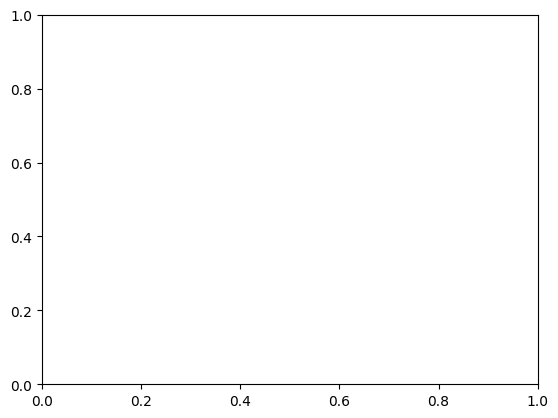

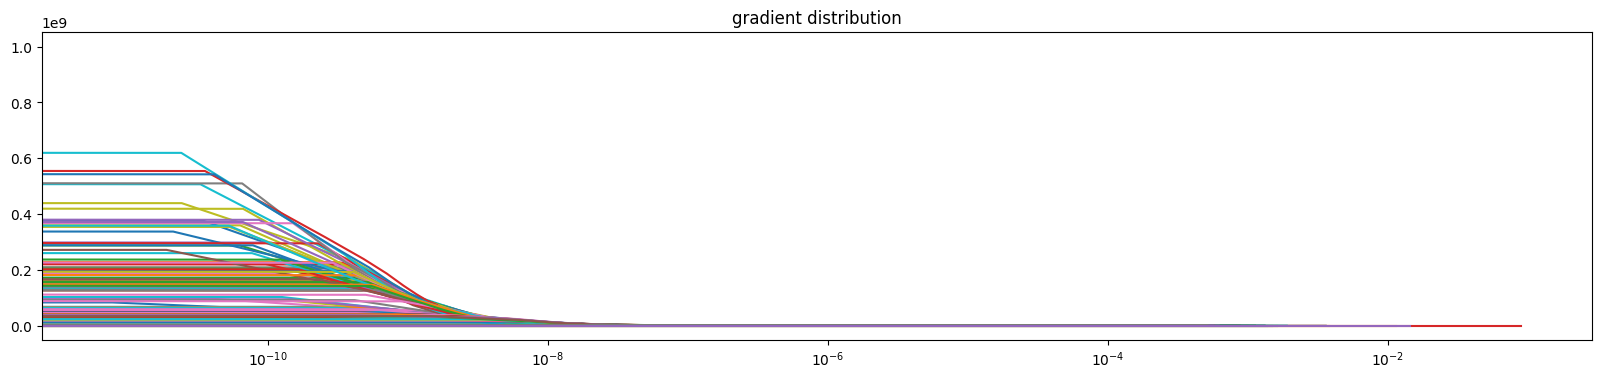

In [13]:
debug_gradients_simple(gradients_dict)

In [33]:
states = ['image_to_emb.weight', 'image_to_emb.bias', 'VIT_transformers.0.att.heads.0.key.weight', 'VIT_transformers.0.att.heads.0.query.weight', 'VIT_transformers.0.att.heads.0.value.weight', 'VIT_transformers.0.att.heads.1.key.weight', 'VIT_transformers.0.att.heads.1.query.weight', 'VIT_transformers.0.att.heads.1.value.weight', 'VIT_transformers.0.att.heads.2.key.weight', 'VIT_transformers.0.att.heads.2.query.weight', 'VIT_transformers.0.att.heads.2.value.weight', 'VIT_transformers.0.att.heads.3.key.weight', 'VIT_transformers.0.att.heads.3.query.weight', 'VIT_transformers.0.att.heads.3.value.weight', 'VIT_transformers.0.att.heads.4.key.weight', 'VIT_transformers.0.att.heads.4.query.weight', 'VIT_transformers.0.att.heads.4.value.weight', 'VIT_transformers.0.att.heads.5.key.weight', 'VIT_transformers.0.att.heads.5.query.weight', 'VIT_transformers.0.att.heads.5.value.weight', 'VIT_transformers.0.att.heads.6.key.weight', 'VIT_transformers.0.att.heads.6.query.weight', 'VIT_transformers.0.att.heads.6.value.weight', 'VIT_transformers.0.att.heads.7.key.weight', 'VIT_transformers.0.att.heads.7.query.weight', 'VIT_transformers.0.att.heads.7.value.weight', 'VIT_transformers.0.att.heads.8.key.weight', 'VIT_transformers.0.att.heads.8.query.weight', 'VIT_transformers.0.att.heads.8.value.weight', 'VIT_transformers.0.att.heads.9.key.weight', 'VIT_transformers.0.att.heads.9.query.weight', 'VIT_transformers.0.att.heads.9.value.weight', 'VIT_transformers.0.att.heads.10.key.weight', 'VIT_transformers.0.att.heads.10.query.weight', 'VIT_transformers.0.att.heads.10.value.weight', 'VIT_transformers.0.att.heads.11.key.weight', 'VIT_transformers.0.att.heads.11.query.weight', 'VIT_transformers.0.att.heads.11.value.weight', 'VIT_transformers.0.att.heads.12.key.weight', 'VIT_transformers.0.att.heads.12.query.weight', 'VIT_transformers.0.att.heads.12.value.weight', 'VIT_transformers.0.att.heads.13.key.weight', 'VIT_transformers.0.att.heads.13.query.weight', 'VIT_transformers.0.att.heads.13.value.weight', 'VIT_transformers.0.att.heads.14.key.weight', 'VIT_transformers.0.att.heads.14.query.weight', 'VIT_transformers.0.att.heads.14.value.weight', 'VIT_transformers.0.att.heads.15.key.weight', 'VIT_transformers.0.att.heads.15.query.weight', 'VIT_transformers.0.att.heads.15.value.weight', 'VIT_transformers.0.att.heads.16.key.weight', 'VIT_transformers.0.att.heads.16.query.weight', 'VIT_transformers.0.att.heads.16.value.weight', 'VIT_transformers.0.att.heads.17.key.weight', 'VIT_transformers.0.att.heads.17.query.weight', 'VIT_transformers.0.att.heads.17.value.weight', 'VIT_transformers.0.att.heads.18.key.weight', 'VIT_transformers.0.att.heads.18.query.weight', 'VIT_transformers.0.att.heads.18.value.weight', 'VIT_transformers.0.att.heads.19.key.weight', 'VIT_transformers.0.att.heads.19.query.weight', 'VIT_transformers.0.att.heads.19.value.weight', 'VIT_transformers.0.att.heads.20.key.weight', 'VIT_transformers.0.att.heads.20.query.weight', 'VIT_transformers.0.att.heads.20.value.weight', 'VIT_transformers.0.att.heads.21.key.weight', 'VIT_transformers.0.att.heads.21.query.weight', 'VIT_transformers.0.att.heads.21.value.weight', 'VIT_transformers.0.att.heads.22.key.weight', 'VIT_transformers.0.att.heads.22.query.weight', 'VIT_transformers.0.att.heads.22.value.weight', 'VIT_transformers.0.att.heads.23.key.weight', 'VIT_transformers.0.att.heads.23.query.weight', 'VIT_transformers.0.att.heads.23.value.weight', 'VIT_transformers.0.att.heads.24.key.weight', 'VIT_transformers.0.att.heads.24.query.weight', 'VIT_transformers.0.att.heads.24.value.weight', 'VIT_transformers.0.att.heads.25.key.weight', 'VIT_transformers.0.att.heads.25.query.weight', 'VIT_transformers.0.att.heads.25.value.weight', 'VIT_transformers.0.att.heads.26.key.weight', 'VIT_transformers.0.att.heads.26.query.weight', 'VIT_transformers.0.att.heads.26.value.weight', 'VIT_transformers.0.att.heads.27.key.weight', 'VIT_transformers.0.att.heads.27.query.weight', 'VIT_transformers.0.att.heads.27.value.weight', 'VIT_transformers.0.att.heads.28.key.weight', 'VIT_transformers.0.att.heads.28.query.weight', 'VIT_transformers.0.att.heads.28.value.weight', 'VIT_transformers.0.att.heads.29.key.weight', 'VIT_transformers.0.att.heads.29.query.weight', 'VIT_transformers.0.att.heads.29.value.weight', 'VIT_transformers.0.att.heads.30.key.weight', 'VIT_transformers.0.att.heads.30.query.weight', 'VIT_transformers.0.att.heads.30.value.weight', 'VIT_transformers.0.att.heads.31.key.weight', 'VIT_transformers.0.att.heads.31.query.weight', 'VIT_transformers.0.att.heads.31.value.weight', 'VIT_transformers.0.att.proj.weight', 'VIT_transformers.0.att.proj.bias', 'VIT_transformers.0.mlp.net.0.weight', 'VIT_transformers.0.mlp.net.0.bias', 'VIT_transformers.0.mlp.net.2.weight', 'VIT_transformers.0.mlp.net.2.bias', 'VIT_transformers.0.ln1.weight', 'VIT_transformers.0.ln1.bias', 'VIT_transformers.0.ln2.weight', 'VIT_transformers.0.ln2.bias', 'VIT_transformers.1.att.heads.0.key.weight', 'VIT_transformers.1.att.heads.0.query.weight', 'VIT_transformers.1.att.heads.0.value.weight', 'VIT_transformers.1.att.heads.1.key.weight', 'VIT_transformers.1.att.heads.1.query.weight', 'VIT_transformers.1.att.heads.1.value.weight', 'VIT_transformers.1.att.heads.2.key.weight', 'VIT_transformers.1.att.heads.2.query.weight', 'VIT_transformers.1.att.heads.2.value.weight', 'VIT_transformers.1.att.heads.3.key.weight', 'VIT_transformers.1.att.heads.3.query.weight', 'VIT_transformers.1.att.heads.3.value.weight', 'VIT_transformers.1.att.heads.4.key.weight', 'VIT_transformers.1.att.heads.4.query.weight', 'VIT_transformers.1.att.heads.4.value.weight', 'VIT_transformers.1.att.heads.5.key.weight', 'VIT_transformers.1.att.heads.5.query.weight', 'VIT_transformers.1.att.heads.5.value.weight', 'VIT_transformers.1.att.heads.6.key.weight', 'VIT_transformers.1.att.heads.6.query.weight', 'VIT_transformers.1.att.heads.6.value.weight', 'VIT_transformers.1.att.heads.7.key.weight', 'VIT_transformers.1.att.heads.7.query.weight', 'VIT_transformers.1.att.heads.7.value.weight', 'VIT_transformers.1.att.heads.8.key.weight', 'VIT_transformers.1.att.heads.8.query.weight', 'VIT_transformers.1.att.heads.8.value.weight', 'VIT_transformers.1.att.heads.9.key.weight', 'VIT_transformers.1.att.heads.9.query.weight', 'VIT_transformers.1.att.heads.9.value.weight', 'VIT_transformers.1.att.heads.10.key.weight', 'VIT_transformers.1.att.heads.10.query.weight', 'VIT_transformers.1.att.heads.10.value.weight', 'VIT_transformers.1.att.heads.11.key.weight', 'VIT_transformers.1.att.heads.11.query.weight', 'VIT_transformers.1.att.heads.11.value.weight', 'VIT_transformers.1.att.heads.12.key.weight', 'VIT_transformers.1.att.heads.12.query.weight', 'VIT_transformers.1.att.heads.12.value.weight', 'VIT_transformers.1.att.heads.13.key.weight', 'VIT_transformers.1.att.heads.13.query.weight', 'VIT_transformers.1.att.heads.13.value.weight', 'VIT_transformers.1.att.heads.14.key.weight', 'VIT_transformers.1.att.heads.14.query.weight', 'VIT_transformers.1.att.heads.14.value.weight', 'VIT_transformers.1.att.heads.15.key.weight', 'VIT_transformers.1.att.heads.15.query.weight', 'VIT_transformers.1.att.heads.15.value.weight', 'VIT_transformers.1.att.heads.16.key.weight', 'VIT_transformers.1.att.heads.16.query.weight', 'VIT_transformers.1.att.heads.16.value.weight', 'VIT_transformers.1.att.heads.17.key.weight', 'VIT_transformers.1.att.heads.17.query.weight', 'VIT_transformers.1.att.heads.17.value.weight', 'VIT_transformers.1.att.heads.18.key.weight', 'VIT_transformers.1.att.heads.18.query.weight', 'VIT_transformers.1.att.heads.18.value.weight', 'VIT_transformers.1.att.heads.19.key.weight', 'VIT_transformers.1.att.heads.19.query.weight', 'VIT_transformers.1.att.heads.19.value.weight', 'VIT_transformers.1.att.heads.20.key.weight', 'VIT_transformers.1.att.heads.20.query.weight', 'VIT_transformers.1.att.heads.20.value.weight', 'VIT_transformers.1.att.heads.21.key.weight', 'VIT_transformers.1.att.heads.21.query.weight', 'VIT_transformers.1.att.heads.21.value.weight', 'VIT_transformers.1.att.heads.22.key.weight', 'VIT_transformers.1.att.heads.22.query.weight', 'VIT_transformers.1.att.heads.22.value.weight', 'VIT_transformers.1.att.heads.23.key.weight', 'VIT_transformers.1.att.heads.23.query.weight', 'VIT_transformers.1.att.heads.23.value.weight', 'VIT_transformers.1.att.heads.24.key.weight', 'VIT_transformers.1.att.heads.24.query.weight', 'VIT_transformers.1.att.heads.24.value.weight', 'VIT_transformers.1.att.heads.25.key.weight', 'VIT_transformers.1.att.heads.25.query.weight', 'VIT_transformers.1.att.heads.25.value.weight', 'VIT_transformers.1.att.heads.26.key.weight', 'VIT_transformers.1.att.heads.26.query.weight', 'VIT_transformers.1.att.heads.26.value.weight', 'VIT_transformers.1.att.heads.27.key.weight', 'VIT_transformers.1.att.heads.27.query.weight', 'VIT_transformers.1.att.heads.27.value.weight', 'VIT_transformers.1.att.heads.28.key.weight', 'VIT_transformers.1.att.heads.28.query.weight', 'VIT_transformers.1.att.heads.28.value.weight', 'VIT_transformers.1.att.heads.29.key.weight', 'VIT_transformers.1.att.heads.29.query.weight', 'VIT_transformers.1.att.heads.29.value.weight', 'VIT_transformers.1.att.heads.30.key.weight', 'VIT_transformers.1.att.heads.30.query.weight', 'VIT_transformers.1.att.heads.30.value.weight', 'VIT_transformers.1.att.heads.31.key.weight', 'VIT_transformers.1.att.heads.31.query.weight', 'VIT_transformers.1.att.heads.31.value.weight', 'VIT_transformers.1.att.proj.weight', 'VIT_transformers.1.att.proj.bias', 'VIT_transformers.1.mlp.net.0.weight', 'VIT_transformers.1.mlp.net.0.bias', 'VIT_transformers.1.mlp.net.2.weight', 'VIT_transformers.1.mlp.net.2.bias', 'VIT_transformers.1.ln1.weight', 'VIT_transformers.1.ln1.bias', 'VIT_transformers.1.ln2.weight', 'VIT_transformers.1.ln2.bias', 'latex_transformers.0.att.heads.0.key.weight', 'latex_transformers.0.att.heads.0.query.weight', 'latex_transformers.0.att.heads.0.value.weight', 'latex_transformers.0.att.heads.1.key.weight', 'latex_transformers.0.att.heads.1.query.weight', 'latex_transformers.0.att.heads.1.value.weight', 'latex_transformers.0.att.heads.2.key.weight', 'latex_transformers.0.att.heads.2.query.weight', 'latex_transformers.0.att.heads.2.value.weight', 'latex_transformers.0.att.heads.3.key.weight', 'latex_transformers.0.att.heads.3.query.weight', 'latex_transformers.0.att.heads.3.value.weight', 'latex_transformers.0.att.heads.4.key.weight', 'latex_transformers.0.att.heads.4.query.weight', 'latex_transformers.0.att.heads.4.value.weight', 'latex_transformers.0.att.heads.5.key.weight', 'latex_transformers.0.att.heads.5.query.weight', 'latex_transformers.0.att.heads.5.value.weight', 'latex_transformers.0.att.heads.6.key.weight', 'latex_transformers.0.att.heads.6.query.weight', 'latex_transformers.0.att.heads.6.value.weight', 'latex_transformers.0.att.heads.7.key.weight', 'latex_transformers.0.att.heads.7.query.weight', 'latex_transformers.0.att.heads.7.value.weight', 'latex_transformers.0.att.heads.8.key.weight', 'latex_transformers.0.att.heads.8.query.weight', 'latex_transformers.0.att.heads.8.value.weight', 'latex_transformers.0.att.heads.9.key.weight', 'latex_transformers.0.att.heads.9.query.weight', 'latex_transformers.0.att.heads.9.value.weight', 'latex_transformers.0.att.heads.10.key.weight', 'latex_transformers.0.att.heads.10.query.weight', 'latex_transformers.0.att.heads.10.value.weight', 'latex_transformers.0.att.heads.11.key.weight', 'latex_transformers.0.att.heads.11.query.weight', 'latex_transformers.0.att.heads.11.value.weight', 'latex_transformers.0.att.heads.12.key.weight', 'latex_transformers.0.att.heads.12.query.weight', 'latex_transformers.0.att.heads.12.value.weight', 'latex_transformers.0.att.heads.13.key.weight', 'latex_transformers.0.att.heads.13.query.weight', 'latex_transformers.0.att.heads.13.value.weight', 'latex_transformers.0.att.heads.14.key.weight', 'latex_transformers.0.att.heads.14.query.weight', 'latex_transformers.0.att.heads.14.value.weight', 'latex_transformers.0.att.heads.15.key.weight', 'latex_transformers.0.att.heads.15.query.weight', 'latex_transformers.0.att.heads.15.value.weight', 'latex_transformers.0.att.heads.16.key.weight', 'latex_transformers.0.att.heads.16.query.weight', 'latex_transformers.0.att.heads.16.value.weight', 'latex_transformers.0.att.heads.17.key.weight', 'latex_transformers.0.att.heads.17.query.weight', 'latex_transformers.0.att.heads.17.value.weight', 'latex_transformers.0.att.heads.18.key.weight', 'latex_transformers.0.att.heads.18.query.weight', 'latex_transformers.0.att.heads.18.value.weight', 'latex_transformers.0.att.heads.19.key.weight', 'latex_transformers.0.att.heads.19.query.weight', 'latex_transformers.0.att.heads.19.value.weight', 'latex_transformers.0.att.heads.20.key.weight', 'latex_transformers.0.att.heads.20.query.weight', 'latex_transformers.0.att.heads.20.value.weight', 'latex_transformers.0.att.heads.21.key.weight', 'latex_transformers.0.att.heads.21.query.weight', 'latex_transformers.0.att.heads.21.value.weight', 'latex_transformers.0.att.heads.22.key.weight', 'latex_transformers.0.att.heads.22.query.weight', 'latex_transformers.0.att.heads.22.value.weight', 'latex_transformers.0.att.heads.23.key.weight', 'latex_transformers.0.att.heads.23.query.weight', 'latex_transformers.0.att.heads.23.value.weight', 'latex_transformers.0.att.heads.24.key.weight', 'latex_transformers.0.att.heads.24.query.weight', 'latex_transformers.0.att.heads.24.value.weight', 'latex_transformers.0.att.heads.25.key.weight', 'latex_transformers.0.att.heads.25.query.weight', 'latex_transformers.0.att.heads.25.value.weight', 'latex_transformers.0.att.heads.26.key.weight', 'latex_transformers.0.att.heads.26.query.weight', 'latex_transformers.0.att.heads.26.value.weight', 'latex_transformers.0.att.heads.27.key.weight', 'latex_transformers.0.att.heads.27.query.weight', 'latex_transformers.0.att.heads.27.value.weight', 'latex_transformers.0.att.heads.28.key.weight', 'latex_transformers.0.att.heads.28.query.weight', 'latex_transformers.0.att.heads.28.value.weight', 'latex_transformers.0.att.heads.29.key.weight', 'latex_transformers.0.att.heads.29.query.weight', 'latex_transformers.0.att.heads.29.value.weight', 'latex_transformers.0.att.heads.30.key.weight', 'latex_transformers.0.att.heads.30.query.weight', 'latex_transformers.0.att.heads.30.value.weight', 'latex_transformers.0.att.heads.31.key.weight', 'latex_transformers.0.att.heads.31.query.weight', 'latex_transformers.0.att.heads.31.value.weight', 'latex_transformers.0.att.proj.weight', 'latex_transformers.0.att.proj.bias', 'latex_transformers.0.mlp.net.0.weight', 'latex_transformers.0.mlp.net.0.bias', 'latex_transformers.0.mlp.net.2.weight', 'latex_transformers.0.mlp.net.2.bias', 'latex_transformers.0.ln1.weight', 'latex_transformers.0.ln1.bias', 'latex_transformers.0.ln2.weight', 'latex_transformers.0.ln2.bias', 'token_embedding_table.weight', 'cross_attention.0.att.heads.0.key.weight', 'cross_attention.0.att.heads.0.query.weight', 'cross_attention.0.att.heads.0.value.weight', 'cross_attention.0.att.heads.1.key.weight', 'cross_attention.0.att.heads.1.query.weight', 'cross_attention.0.att.heads.1.value.weight', 'cross_attention.0.att.heads.2.key.weight', 'cross_attention.0.att.heads.2.query.weight', 'cross_attention.0.att.heads.2.value.weight', 'cross_attention.0.att.heads.3.key.weight', 'cross_attention.0.att.heads.3.query.weight', 'cross_attention.0.att.heads.3.value.weight', 'cross_attention.0.att.heads.4.key.weight', 'cross_attention.0.att.heads.4.query.weight', 'cross_attention.0.att.heads.4.value.weight', 'cross_attention.0.att.heads.5.key.weight', 'cross_attention.0.att.heads.5.query.weight', 'cross_attention.0.att.heads.5.value.weight', 'cross_attention.0.att.heads.6.key.weight', 'cross_attention.0.att.heads.6.query.weight', 'cross_attention.0.att.heads.6.value.weight', 'cross_attention.0.att.heads.7.key.weight', 'cross_attention.0.att.heads.7.query.weight', 'cross_attention.0.att.heads.7.value.weight', 'cross_attention.0.att.heads.8.key.weight', 'cross_attention.0.att.heads.8.query.weight', 'cross_attention.0.att.heads.8.value.weight', 'cross_attention.0.att.heads.9.key.weight', 'cross_attention.0.att.heads.9.query.weight', 'cross_attention.0.att.heads.9.value.weight', 'cross_attention.0.att.heads.10.key.weight', 'cross_attention.0.att.heads.10.query.weight', 'cross_attention.0.att.heads.10.value.weight', 'cross_attention.0.att.heads.11.key.weight', 'cross_attention.0.att.heads.11.query.weight', 'cross_attention.0.att.heads.11.value.weight', 'cross_attention.0.att.heads.12.key.weight', 'cross_attention.0.att.heads.12.query.weight', 'cross_attention.0.att.heads.12.value.weight', 'cross_attention.0.att.heads.13.key.weight', 'cross_attention.0.att.heads.13.query.weight', 'cross_attention.0.att.heads.13.value.weight', 'cross_attention.0.att.heads.14.key.weight', 'cross_attention.0.att.heads.14.query.weight', 'cross_attention.0.att.heads.14.value.weight', 'cross_attention.0.att.heads.15.key.weight', 'cross_attention.0.att.heads.15.query.weight', 'cross_attention.0.att.heads.15.value.weight', 'cross_attention.0.att.heads.16.key.weight', 'cross_attention.0.att.heads.16.query.weight', 'cross_attention.0.att.heads.16.value.weight', 'cross_attention.0.att.heads.17.key.weight', 'cross_attention.0.att.heads.17.query.weight', 'cross_attention.0.att.heads.17.value.weight', 'cross_attention.0.att.heads.18.key.weight', 'cross_attention.0.att.heads.18.query.weight', 'cross_attention.0.att.heads.18.value.weight', 'cross_attention.0.att.heads.19.key.weight', 'cross_attention.0.att.heads.19.query.weight', 'cross_attention.0.att.heads.19.value.weight', 'cross_attention.0.att.heads.20.key.weight', 'cross_attention.0.att.heads.20.query.weight', 'cross_attention.0.att.heads.20.value.weight', 'cross_attention.0.att.heads.21.key.weight', 'cross_attention.0.att.heads.21.query.weight', 'cross_attention.0.att.heads.21.value.weight', 'cross_attention.0.att.heads.22.key.weight', 'cross_attention.0.att.heads.22.query.weight', 'cross_attention.0.att.heads.22.value.weight', 'cross_attention.0.att.heads.23.key.weight', 'cross_attention.0.att.heads.23.query.weight', 'cross_attention.0.att.heads.23.value.weight', 'cross_attention.0.att.heads.24.key.weight', 'cross_attention.0.att.heads.24.query.weight', 'cross_attention.0.att.heads.24.value.weight', 'cross_attention.0.att.heads.25.key.weight', 'cross_attention.0.att.heads.25.query.weight', 'cross_attention.0.att.heads.25.value.weight', 'cross_attention.0.att.heads.26.key.weight', 'cross_attention.0.att.heads.26.query.weight', 'cross_attention.0.att.heads.26.value.weight', 'cross_attention.0.att.heads.27.key.weight', 'cross_attention.0.att.heads.27.query.weight', 'cross_attention.0.att.heads.27.value.weight', 'cross_attention.0.att.heads.28.key.weight', 'cross_attention.0.att.heads.28.query.weight', 'cross_attention.0.att.heads.28.value.weight', 'cross_attention.0.att.heads.29.key.weight', 'cross_attention.0.att.heads.29.query.weight', 'cross_attention.0.att.heads.29.value.weight', 'cross_attention.0.att.heads.30.key.weight', 'cross_attention.0.att.heads.30.query.weight', 'cross_attention.0.att.heads.30.value.weight', 'cross_attention.0.att.heads.31.key.weight', 'cross_attention.0.att.heads.31.query.weight', 'cross_attention.0.att.heads.31.value.weight', 'cross_attention.0.att.proj.weight', 'cross_attention.0.att.proj.bias', 'cross_attention.0.mlp.net.0.weight', 'cross_attention.0.mlp.net.0.bias', 'cross_attention.0.mlp.net.2.weight', 'cross_attention.0.mlp.net.2.bias', 'cross_attention.0.ln1.weight', 'cross_attention.0.ln1.bias', 'cross_attention.0.ln2.weight', 'cross_attention.0.ln2.bias', 'final_mlp.net.0.weight', 'final_mlp.net.0.bias', 'final_mlp.net.2.weight', 'final_mlp.net.2.bias']

rendored_states = []
for i in states:
    rendored_states.append(i.split(".")[0])

rendored_states = list(set(rendored_states))


In [34]:
rendored_states

['cross_attention',
 'VIT_transformers',
 'latex_transformers',
 'token_embedding_table',
 'image_to_emb',
 'final_mlp']

In [35]:
states_without_finalmlp = ['token_embedding_table',
 'VIT_transformers',
 'cross_attention',
 'latex_transformers',
 'image_to_emb']

In [27]:
import matplotlib.pyplot as plt

def debug_gradients(gradients_dict, rendored_states):
    fig, ax = plt.subplots()
    legends = []
    for state in rendored_states:  # График для каждого блока сети



        dict_for_layers = {}

        for layer, value in gradients_dict.items():
            # Проверяем, содержит ли название слоя текущее состояние
            if state in layer:
                if value == None:
                    continue
                temp = value.clone()
                temp = temp.to("cpu")
                if state in dict_for_layers:
                    dict_for_layers[state].append(temp.reshape(-1))
                else:
                    dict_for_layers[state] = [temp.reshape(-1)]

        for layer in dict_for_layers:
            temp = torch.cat(dict_for_layers[layer])
            hy, hx = torch.histogram(temp, density=True)
            ax.plot(hx[:-1].detach(), hy.detach(), alpha=0.7)  # alpha для наглядности
            ax.set_yscale('log')
            #line1, = ax.plot([1, 2, 3], label="Line 1", linestyle='--')
            legends.append(f"{layer}")

    plt.legend(legends, fontsize=8)  # меньший шрифт для легенды
    plt.title(f"Gradient distribution")
    plt.grid(True, alpha=0.3)  # добавляем сетку для удобства
    ax.set_xlim(-0.001, 0.001)
    plt.show()  # Показываем график перед следующим


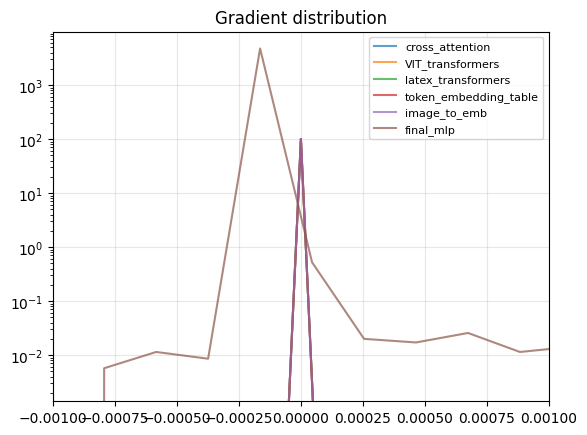

In [28]:
debug_gradients(gradients_dict, rendored_states)

In [19]:
cnt

14

In [121]:
len(losses)

348

In [ ]:
import numpy as np
def show_loss(losses):
    plt.plot(np.arange(1., len(losses) + 1, 5), losses)
    plt.ylabel('NLL-loss')
    plt.xlabel('iteration of learning')
    plt.axis((0, len(losses), 0, 6))

    plt.show()

In [19]:
import pickle
import matplotlib.pyplot as plt

with open('checkpoints_first/loss_logs.pkl', 'rb') as file:
    old_losses = pickle.load(file)

def show_loss_compare(losses, old_losses):
    plt.plot(np.arange(1., 500 + 1, 1), losses[:500], label="modified model")
    plt.plot(np.arange(1., 500 + 1, 1), old_losses[:500], label="old model")
    plt.ylabel('NLL-loss')
    plt.xlabel('iteration of learning')
    plt.axis((0, len(losses), 0, 6))
    plt.legend()  # добавление подписей (легенды)
    plt.show()

In [18]:
len(losses)

1340

In [5]:
import pickle

with open('checkpoints_25.03.26/loss_logs.pkl', 'rb') as file:
    losses = pickle.load(file)

In [16]:
old_losses

[5.7110700607299805,
 5.513498306274414,
 5.30213737487793,
 5.065742015838623,
 4.862826347351074,
 4.591391563415527,
 4.5999226570129395,
 4.5558366775512695,
 4.449423789978027,
 4.460473537445068,
 4.410348415374756,
 4.380719184875488,
 4.444042682647705,
 4.389247417449951,
 4.323709011077881,
 4.342374801635742,
 4.324606895446777,
 4.279643535614014,
 4.314044952392578,
 4.310001850128174,
 4.239719867706299,
 4.265271186828613,
 4.22114372253418,
 4.276939392089844,
 4.2765889167785645,
 4.2125067710876465,
 4.165872573852539,
 4.196314811706543,
 4.168086051940918,
 4.206296443939209,
 4.2403693199157715,
 4.12232780456543,
 4.115102767944336,
 4.145140171051025,
 4.183992862701416,
 4.194055557250977,
 4.18027400970459,
 4.135145664215088,
 4.056015968322754,
 4.14985990524292,
 4.134455680847168,
 4.099221229553223,
 4.115567207336426,
 4.06878137588501,
 4.171871185302734,
 4.014838695526123,
 4.0908002853393555,
 4.080106735229492,
 4.061453819274902,
 3.9816982746124268

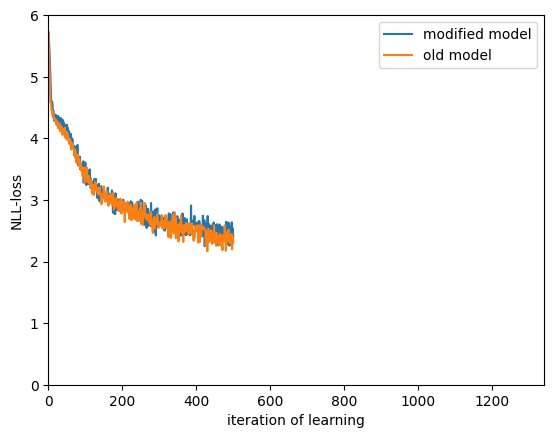

In [21]:
show_loss_compare(losses, old_losses)

In [13]:
losses

[5.732925891876221,
 5.558829307556152,
 5.3739824295043945,
 5.155789852142334,
 4.901140213012695,
 4.798840522766113,
 4.635703086853027,
 4.567206859588623,
 4.450345516204834,
 4.43366003036499,
 4.365915775299072,
 4.398263454437256,
 4.410211563110352,
 4.362584590911865,
 4.246038913726807,
 4.297886371612549,
 4.292551040649414,
 4.294127464294434,
 4.280762195587158,
 4.26472282409668]

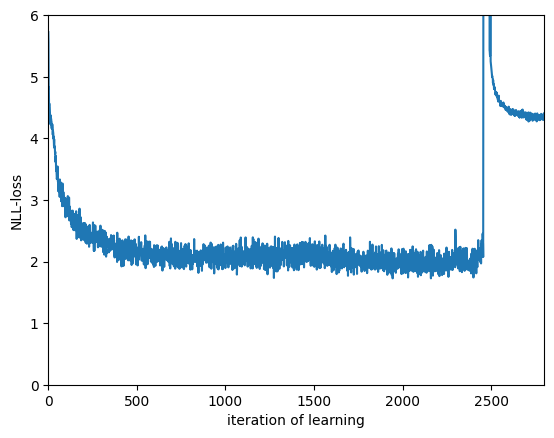

In [30]:
show_loss(losses)

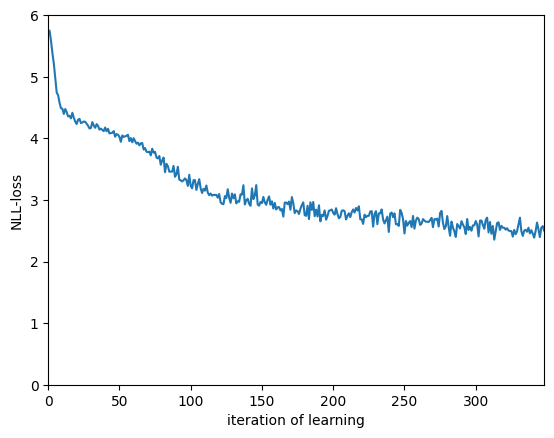

In [28]:
show_loss(losses)

In [20]:
import pickle

with open('checkpoints_28.03.26/loss_logs.pkl', 'wb') as file:
    pickle.dump(losses, file)

In [5]:
model

FormulaAI(
  (image_to_emb): Linear(in_features=400, out_features=512, bias=True)
  (VIT_transformers): Sequential(
    (0): ResViTBlock(
      (att): MultiHeadAttention(
        (heads): ModuleList(
          (0-31): 32 x AttentionHead(
            (key): Linear(in_features=512, out_features=128, bias=False)
            (query): Linear(in_features=512, out_features=128, bias=False)
            (value): Linear(in_features=512, out_features=128, bias=False)
          )
        )
        (proj): Linear(in_features=4096, out_features=512, bias=True)
      )
      (mlp): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=512, out_features=2048, bias=True)
          (1): ReLU()
          (2): Linear(in_features=2048, out_features=512, bias=True)
        )
      )
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
    (1): ResViTBlock(
      (att): MultiHeadAttention(
        (head

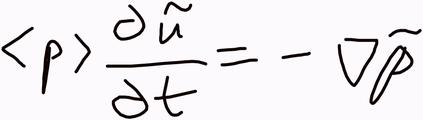

In [4]:
ds_train.dataset[300]["image"]

In [8]:
from torchvision import transforms
from prepare_data import SmartResizer
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

presee_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Lambda(lambda x: ImageOps.invert(x)),
    transforms.ToTensor(),
    SmartResizer(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

In [9]:
ds_train.dataset[300]["image"].size

(423, 120)

In [10]:
s_to_test = presee_transform(ds_train.dataset[300]["image"]).squeeze()

In [11]:
s_to_test[40]

tensor([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -

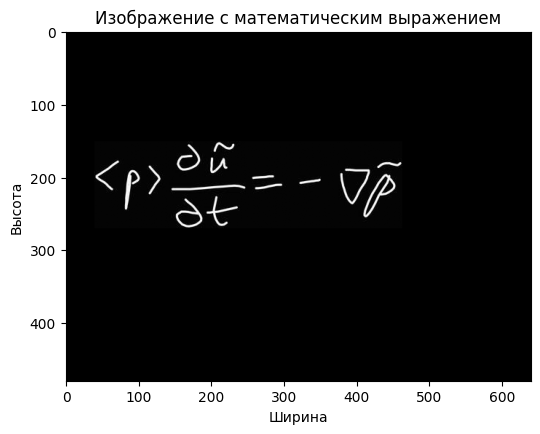

In [12]:
plt.figure(figsize=(6, 6))
plt.imshow(s_to_test, cmap='gray') # Отображаем данные с цветовой картой 'gray'
#plt.colorbar(label='Интенсивность пикселя')
plt.title('Изображение с математическим выражением')
plt.xlabel('Ширина')
plt.ylabel('Высота')
plt.show()

In [12]:
Tkn.decode(ds_train[300][2])

'\\langle\\rho\\rangle\\frac{\\partial\\tilde{u}}{\\partial t}=-\\nabla\\tilde{p}'

In [13]:
ds_train[300][0].unsqueeze(0).size()

torch.Size([1, 768, 400])

In [ ]:
for i in range(len(ds_train)):

    ds_train[i]

In [14]:
gen_out = model.generate((ds_train[300][0].unsqueeze(0), torch.tensor([301]).unsqueeze(0)), 30)

In [15]:
gen_out = gen_out.to("cpu")

In [16]:
gen_out.tolist()[0]

[301,
 92,
 111,
 118,
 101,
 114,
 108,
 265,
 295,
 92,
 108,
 286,
 114,
 112,
 125,
 257,
 49,
 125,
 278,
 125,
 278,
 125,
 278,
 125,
 302,
 257,
 50,
 125,
 278,
 125,
 278]

In [17]:
gen_out

tensor([[301,  92, 111, 118, 101, 114, 108, 265, 295,  92, 108, 286, 114, 112,
         125, 257,  49, 125, 278, 125, 278, 125, 278, 125, 302, 257,  50, 125,
         278, 125, 278]])

In [18]:
Tkn.decode(gen_out.tolist()[0])

'\\overline{\\ltarp}_{1}^{2}^{2}^{2}_{2}^{2}^{2'

In [72]:
ds_train[300]

(tensor([[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]]),
 tensor([301,  92, 108,  97, 110, 103, 108, 101,  92, 114, 104, 111,  92, 259,
         110, 103, 108, 101, 263, 271,  97, 266, 105, 284,  92, 116, 105, 108,
         100, 295, 117, 280, 271,  97, 266, 105, 284,  32, 116, 281,  45,  92,
         110,  97,  98, 108,  97,  92, 116, 105, 108, 100, 295, 112, 125, 303,
         303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303,
         303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303,
         303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303,
         303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303,
         303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 3

In [41]:
attention_matrixes = []

In [43]:
single_dataset = Subset(ds_train, [300])  # [301] - список индексов

In [45]:
single_dataset[0]

[tensor([[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]),
 [301,
  92,
  108,
  97,
  110,
  103,
  108,
  101,
  92,
  114,
  104,
  111,
  92,
  259,
  110,
  103,
  108,
  101,
  263,
  271,
  97,
  266,
  105,
  284,
  92,
  116,
  105,
  108,
  100,
  295,
  117,
  280,
  271,
  97,
  266,
  105,
  284,
  32,
  116,
  281,
  45,
  92,
  110,
  97,
  98,
  108,
  97,
  92,
  116,
  105,
  108,
  100,
  295,
  112,
  125],
 [92,
  108,
  97,
  110,
  103,
  108,
  101,
  92,
  114,
  104,
  111,
  92,
  259,
  110,
  103,
  108,
  101,
  263,
  271,
  97,
  266,
  105,
  284,
  92,
  116,
  105,
  108,
  100,
  295,
  117,
  280,
  271,
  97,
  266,
  105,
  284,
  32,
  116,
  281,
  45,
  92,
  110,
  97,
  98,
  108,
  97,
  92,
  116,
  105,
  108,
  100,
  295,
  112,
  125,
  

In [24]:
attention_matrix = []

In [25]:
from contextlib import contextmanager
from typing import Callable, Tuple
from prepare_data import padding_in_batch

def compute_attention_image_matrix(layer: torch.nn.Module, inputs: Tuple[torch.Tensor], _output: torch.Tensor):
    if type(layer) == AttentionHead:
        # x_h = inputs[0]
        # B, T, C = x_h.shape
        # k_h = layer.key(x_h)
        # k_h = apply_rotary_2D_embeddings(k_h, layer.freqs_complex_x, layer.freqs_complex_y)
        # q_h = layer.query(x_h)
        # q_h = apply_rotary_2D_embeddings(q_h, layer.freqs_complex_x, layer.freqs_complex_y)
        # wei_h = (q_h @ k_h.transpose(-2, -1) / (C ** 0.5))
        # attention_matrixes.append(wei_h)
        x = inputs[0]
        B, T, C = x.shape # (batch, count of elements, count of features)
        k = layer.key(x) # (B, T, N_head * head_size)
        k = torch.reshape(k, (B, T, N_HEAD_ATTENTION, layer.head_size))
        k = k.permute(0, 2, 1, 3) # (B, N_head, T, head_size)
        k = apply_rotary_2D_embeddings(k, layer.freqs_complex_x, layer.freqs_complex_y)

        q = layer.query(x) # (B, T, N_head * head_size)
        q = torch.reshape(q, (B, T, N_HEAD_ATTENTION, layer.head_size))
        q = q.permute(0, 2, 1, 3) # (B, N_head, T, head_size)
        q = apply_rotary_2D_embeddings(q, layer.freqs_complex_x, layer.freqs_complex_y)

        v = layer.value(x) # (B, N_head, T, head_size)
        v = torch.reshape(v, (B, T, N_HEAD_ATTENTION, layer.head_size))
        v = v.permute(0, 2, 1, 3) # (B, N_head, T, head_size)
        wei = (q @ k.transpose(-2, -1) / (layer.head_size ** 0.5))  # (B, N_heads, T, T)
        softwei = F.softmax(wei, dim=-1)
        out = softwei @ v
        attention_matrix.append(softwei)

@contextmanager
def module_hook(hook: Callable):
    handle = torch.nn.modules.module.register_module_forward_hook(hook, always_call=True)
    try:
        yield
    finally:
        handle.remove()  # ← критически важно

from torch.utils.data import DataLoader, Subset

# Создаём датасет из одного примера
single_dataset = Subset(ds_train, [300])  # [301] - список индексов
single_loader = DataLoader(single_dataset, batch_size=1, collate_fn=padding_in_batch)

# Используем
model.eval()
with module_hook(compute_attention_image_matrix):
    with torch.no_grad():
        for x in single_loader:  # одна итерация
            output = model(x)


In [26]:
attention_matrix

[tensor([[[[4.5498e-12, 6.5684e-12, 8.0399e-12,  ..., 3.8132e-09,
            2.9718e-09, 2.4862e-09],
           [2.4230e-12, 3.8810e-12, 5.6029e-12,  ..., 4.0525e-09,
            3.2527e-09, 2.5350e-09],
           [1.2737e-12, 2.0379e-12, 3.2643e-12,  ..., 3.7712e-09,
            3.4085e-09, 2.7358e-09],
           ...,
           [7.3086e-11, 5.2524e-11, 4.3208e-11,  ..., 2.2042e-13,
            3.1821e-13, 3.8950e-13],
           [1.7217e-10, 1.1171e-10, 8.0282e-11,  ..., 2.1033e-13,
            3.3690e-13, 4.8638e-13],
           [3.3190e-10, 2.1587e-10, 1.4006e-10,  ..., 1.6483e-13,
            2.6372e-13, 4.2242e-13]],
 
          [[1.5414e-06, 2.0582e-06, 2.5614e-06,  ..., 1.0047e-07,
            5.0073e-08, 2.5973e-08],
           [1.1855e-06, 1.5532e-06, 2.0740e-06,  ..., 1.6526e-07,
            1.0124e-07, 5.0457e-08],
           [1.3956e-06, 2.0202e-06, 2.6469e-06,  ..., 3.3816e-07,
            2.8163e-07, 1.7253e-07],
           ...,
           [1.0830e-07, 4.7604e-08, 1.

In [27]:
attention_matrix[0].size()

torch.Size([1, 32, 768, 768])

In [47]:
output

(tensor([[-11.0670, -11.1841, -12.0846,  ..., -10.9880,  -3.9110, -11.5456],
         [-11.1928, -11.9861, -12.1239,  ..., -10.1994,  -3.5033, -11.7646],
         [-17.2577, -17.0873, -16.6905,  ..., -15.2986,  -4.7022, -15.7613],
         ...,
         [-12.0191, -11.9148, -12.1144,  ..., -10.9411,  -5.5949, -11.1128],
         [-13.2763, -14.1868, -13.6882,  ..., -13.4010,   2.5722, -13.5622],
         [-11.9964, -12.2799, -12.5332,  ..., -10.7146,   5.7844, -11.0641]],
        device='cuda:0'),
 tensor(2.1872, device='cuda:0'))

In [90]:
attention_matrixes

[tensor([[[-5.8744, -5.8081, -5.9132,  ..., -4.8490, -4.8696, -4.7661],
          [-6.1021, -5.8744, -5.8081,  ..., -4.7273, -4.8490, -4.8696],
          [-6.4140, -6.1021, -5.8744,  ..., -4.5815, -4.7273, -4.8490],
          ...,
          [-4.9082, -4.9775, -4.9420,  ..., -5.8744, -5.8081, -5.9132],
          [-4.7285, -4.9082, -4.9775,  ..., -6.1021, -5.8744, -5.8081],
          [-4.4917, -4.7285, -4.9082,  ..., -6.4140, -6.1021, -5.8744]]],
        device='cuda:0'),
 tensor([[[-4.7621, -4.4990, -4.3400,  ..., -6.1742, -6.1961, -6.1084],
          [-5.1056, -4.7621, -4.4990,  ..., -6.0674, -6.1742, -6.1961],
          [-5.5042, -5.1056, -4.7621,  ..., -5.9067, -6.0674, -6.1742],
          ...,
          [-5.6573, -6.0094, -6.2725,  ..., -4.7621, -4.4990, -4.3400],
          [-5.2255, -5.6573, -6.0094,  ..., -5.1056, -4.7621, -4.4990],
          [-4.7335, -5.2255, -5.6573,  ..., -5.5042, -5.1056, -4.7621]]],
        device='cuda:0'),
 tensor([[[ 2.5205,  2.3952,  2.6788,  ...,  0.016

In [38]:
len(attention_matrix)

2

In [28]:
attention_matrix[0].size()

torch.Size([1, 32, 768, 768])

In [29]:
attention_matrix = attention_matrix[0].squeeze().to("cpu")

In [30]:
attention_matrix[0][0].sum()

tensor(1.0000)

In [31]:
attention_matrix.size()

torch.Size([32, 768, 768])

In [46]:
attention_matrix

tensor([[[1.2738e-13, 1.8389e-13, 2.2509e-13,  ..., 1.0676e-10,
          8.3201e-11, 6.9604e-11],
         [3.0292e-14, 4.8521e-14, 7.0049e-14,  ..., 5.0666e-11,
          4.0666e-11, 3.1693e-11],
         [8.2402e-15, 1.3184e-14, 2.1118e-14,  ..., 2.4397e-11,
          2.2051e-11, 1.7699e-11],
         ...,
         [1.4116e-10, 1.0145e-10, 8.3452e-11,  ..., 4.2572e-13,
          6.1460e-13, 7.5228e-13],
         [2.2864e-10, 1.4835e-10, 1.0661e-10,  ..., 2.7931e-13,
          4.4739e-13, 6.4589e-13],
         [4.1762e-10, 2.7163e-10, 1.7624e-10,  ..., 2.0740e-13,
          3.3183e-13, 5.3151e-13]],

        [[1.2859e-07, 1.7170e-07, 2.1369e-07,  ..., 8.3819e-09,
          4.1773e-09, 2.1668e-09],
         [2.0368e-07, 2.6687e-07, 3.5634e-07,  ..., 2.8394e-08,
          1.7395e-08, 8.6691e-09],
         [2.6144e-07, 3.7845e-07, 4.9585e-07,  ..., 6.3348e-08,
          5.2758e-08, 3.2321e-08],
         ...,
         [5.5276e-07, 2.4296e-07, 9.2095e-08,  ..., 2.0157e-05,
          2.691

In [26]:
test_for_deep_analyze = F.softmax(attention_matrix[0].squeeze().to("cpu"), dim=-1)

In [27]:
test_for_deep_analyze.size()

torch.Size([32, 768, 128])

In [31]:
test_for_deep_analyze.size()

torch.Size([32, 768, 128])

In [59]:
ds_train[300]

[tensor([[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]),
 [301,
  92,
  108,
  97,
  110,
  103,
  108,
  101,
  92,
  114,
  104,
  111,
  92,
  259,
  110,
  103,
  108,
  101,
  263,
  271,
  97,
  266,
  105,
  284,
  92,
  116,
  105,
  108,
  100,
  295,
  117,
  280,
  271,
  97,
  266,
  105,
  284,
  32,
  116,
  281,
  45,
  92,
  110,
  97,
  98,
  108,
  97,
  92,
  116,
  105,
  108,
  100,
  295,
  112,
  125],
 [92,
  108,
  97,
  110,
  103,
  108,
  101,
  92,
  114,
  104,
  111,
  92,
  259,
  110,
  103,
  108,
  101,
  263,
  271,
  97,
  266,
  105,
  284,
  92,
  116,
  105,
  108,
  100,
  295,
  117,
  280,
  271,
  97,
  266,
  105,
  284,
  32,
  116,
  281,
  45,
  92,
  110,
  97,
  98,
  108,
  97,
  92,
  116,
  105,
  108,
  100,
  295,
  112,
  125,
  

In [112]:
test_for_deep_analyze_cpu = test_for_deep_analyze.to("cpu")

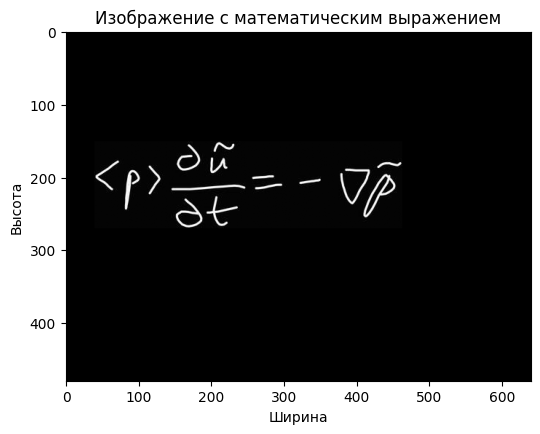

In [32]:
plt.figure(figsize=(6, 6))
plt.imshow(s_to_test, cmap='gray') # Отображаем данные с цветовой картой 'gray'
#plt.colorbar(label='Интенсивность пикселя')
plt.title('Изображение с математическим выражением')
plt.xlabel('Ширина')
plt.ylabel('Высота')
plt.show()

In [41]:
s_to_test.size()

torch.Size([480, 640])

In [31]:
test_for_deep_analyze.size()

torch.Size([32, 768, 128])

In [70]:
test_for_deep_analyze_cpu

tensor([[2.9050e-06, 2.5790e-06, 1.9708e-06,  ..., 2.3555e-06, 2.7308e-06,
         2.1177e-06],
        [2.2642e-06, 2.5731e-06, 2.2844e-06,  ..., 1.6421e-06, 2.0864e-06,
         2.4188e-06],
        [1.8793e-06, 1.9797e-06, 2.2498e-06,  ..., 9.4152e-07, 1.4358e-06,
         1.8242e-06],
        ...,
        [1.3972e-05, 1.1633e-05, 8.6791e-06,  ..., 6.6878e-06, 5.9374e-06,
         4.5370e-06],
        [1.2186e-05, 1.3584e-05, 1.1310e-05,  ..., 5.7216e-06, 6.5021e-06,
         5.7725e-06],
        [6.0998e-06, 1.2780e-05, 1.4246e-05,  ..., 5.6960e-06, 6.0006e-06,
         6.8191e-06]])

In [33]:
test_for_deep_analyze[0][150][358]

IndexError: index 358 is out of bounds for dimension 0 with size 128

In [98]:
torch.tensor(0.4)

tensor(0.4000)

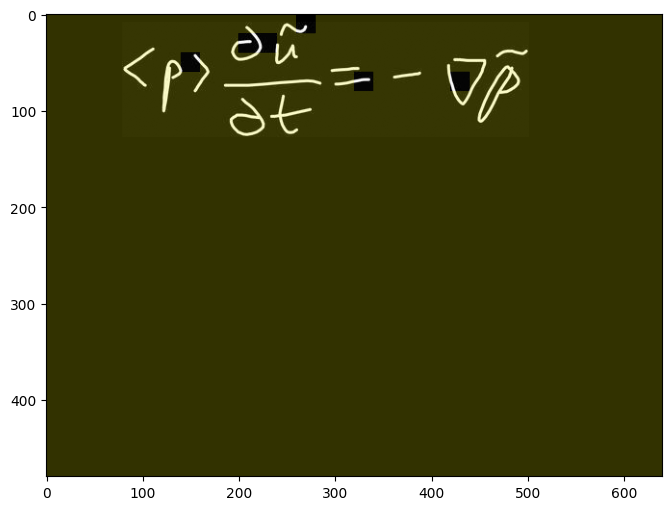

In [48]:
import numpy as np
plt.figure(figsize=(8, 6))
plt.imshow(s_to_test, cmap='gray')
mask = np.zeros_like(s_to_test, dtype=bool)

for qi in range(768):
    for ki in range(768):
        if attention_matrix[0][qi][ki] > torch.tensor(0.1):
            q1 = (qi // 32) * 20
            q2 = (qi % 32) * 20
            for i in range(q1, q1 + 20):
                for j in range(q2, q2 + 20):
                    mask[i, j] = True

            k1 = (ki // 32) * 20
            k2 = (ki % 32) * 20
            for i in range(k1, k1 + 20):
                for j in range(k2, k2 + 20):
                    mask[i, j] = True


color_overlay = np.zeros((*s_to_test.shape, 4))
color_overlay[mask] = [1, 1, 0, 0.5]  # красный
plt.imshow(color_overlay, alpha=0.4)
plt.show()

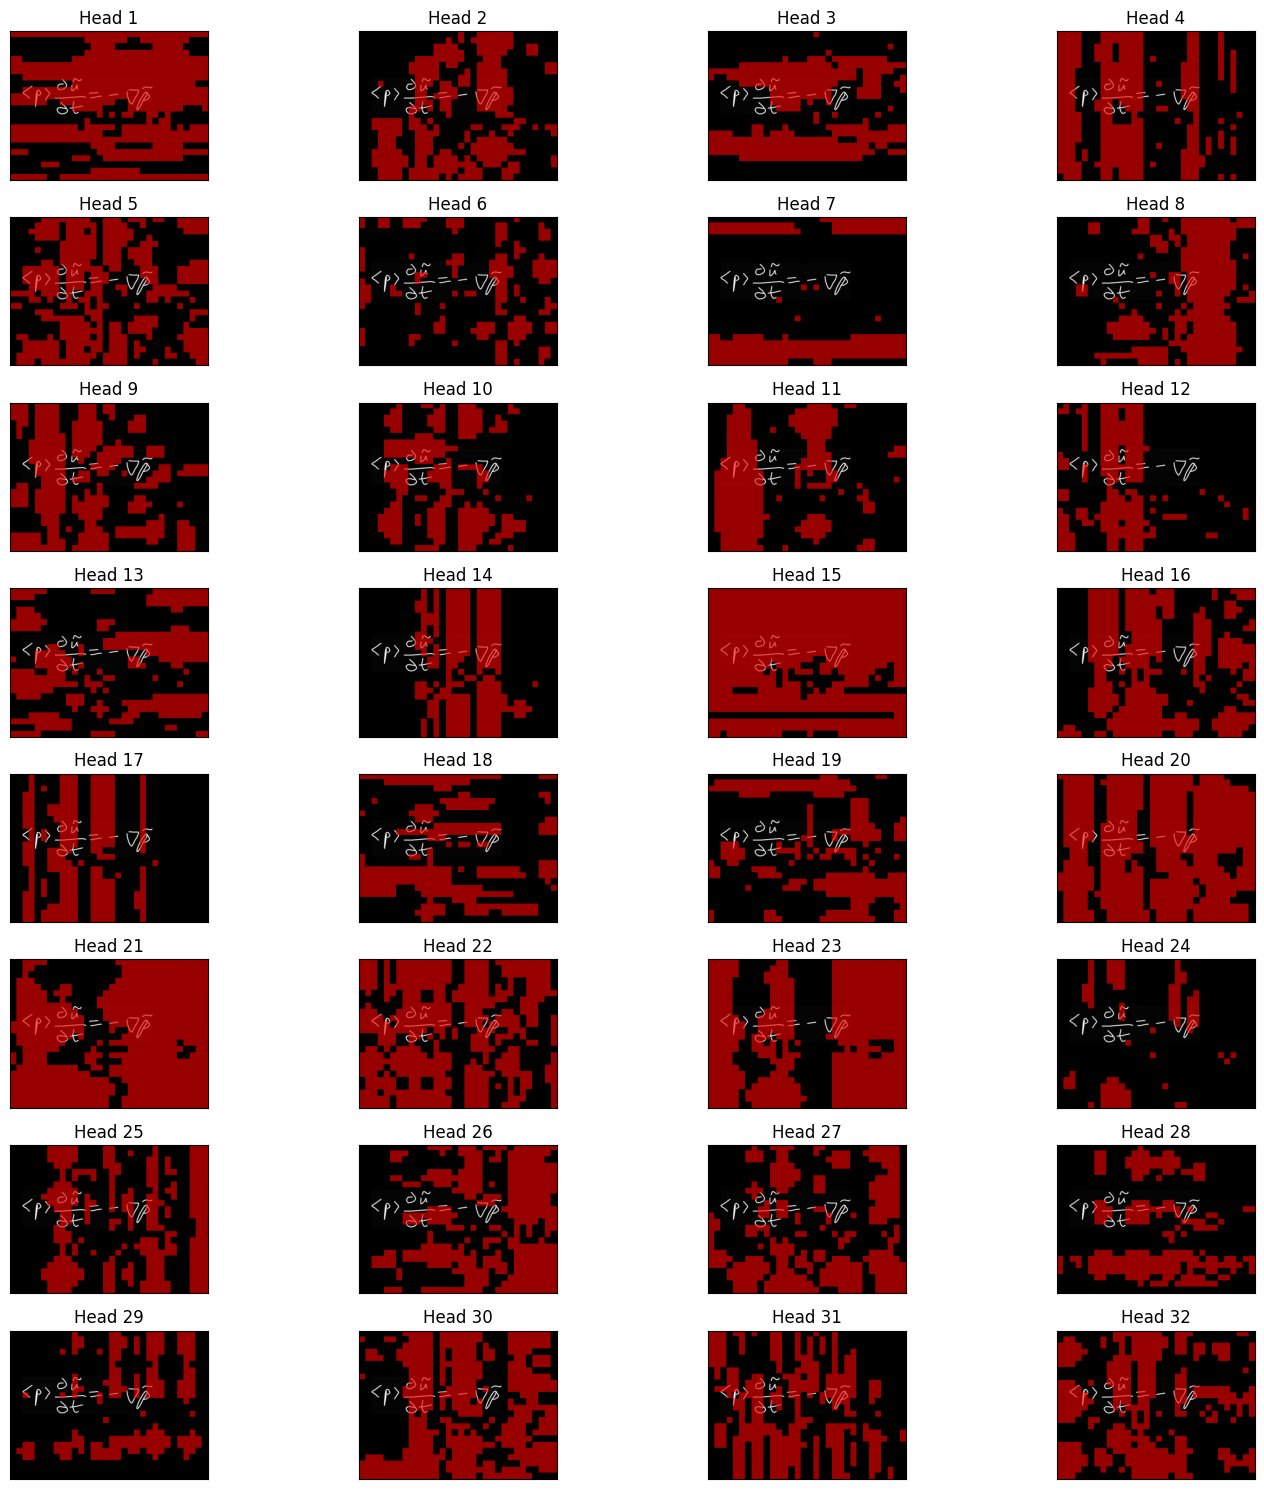

In [36]:
import numpy as np
fig, axes = plt.subplots(8, 4, figsize=(15, 15))  # 2 строки, 5 столбцов
axes = axes.flatten()  # делаем одномерный массив для удобного доступа

for idx in range(32):
    ax = axes[idx]

    # Отображаем grayscale
    #test_for_deep_analyze_cur = F.softmax(attention_matrixes[idx].squeeze(), dim=-1).to("cpu")
    im = ax.imshow(s_to_test, cmap='gray', aspect='auto')

    # Создаем маску
    mask = np.zeros_like(s_to_test, dtype=bool)

    for qi in range(768):
        for ki in range(768):
            if attention_matrix[idx][qi][ki] > torch.tensor(0.8):
                q1 = (qi // 32) * 20
                q2 = (qi % 32) * 20
                for i in range(q1, min(q1 + 20, 768)):
                    for j in range(q2, min(q2 + 20, 768)):
                        mask[i, j] = True

                k1 = (ki // 32) * 20
                k2 = (ki % 32) * 20
                for i in range(k1, min(k1 + 20, 768)):
                    for j in range(k2, min(k2 + 20, 768)):
                        mask[i, j] = True

    # Накладываем цветной слой
    color_overlay = np.zeros((*s_to_test.shape, 4))
    color_overlay[mask] = [1, 0, 0, 0.6]
    ax.imshow(color_overlay)

    ax.set_title(f'Head {idx+1}')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [6]:
verytempp = 0
for sample in dl_train:
    print(sample[1].size())
    print(Tkn.mask_padding(sample[1]).size())
    verytempp += 1
    if verytempp == 10:
        break

torch.Size([42, 30])


In [2]:
len(dl_train)

5473